Se utiliza:
    {'n_estimators': 5, 'tree_max_depth': 3, 'c': 0.25},

# 1. Import and load

In [1]:
import os
from pathlib import Path
import sys
import pickle as pk
import numpy as np
import pandas as pd

project_root = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.append(project_root)
sys.path.append(os.path.join(project_root, 'src', 'model'))
sys.path.append(os.path.join(project_root, 'src', 'rules'))
sys.path.append(os.path.join(project_root, 'src', 'fuzzy'))

from rulecosi import RuleCOSIClassifier
from src.model import train_model as mod
from config import LOAN_FILE, MODEL_DIR, PKL_DIR
import glob

# Cargar la porción COSI (datos que el modelo base nunca vio)
X_train_cosi = pd.read_pickle(os.path.join(PKL_DIR, 'X_train_cosi.pkl'))
y_train_cosi = pd.read_pickle(os.path.join(PKL_DIR, 'y_train_cosi.pkl'))

X_test = pd.read_pickle(os.path.join(PKL_DIR, 'X_test.pkl'))
y_test = pd.read_pickle(os.path.join(PKL_DIR, 'y_test.pkl'))


In [2]:
# Carga del modelo base CatBoost
pklList = mod.read_all_pkl_files(PKL_DIR)
prefix  = 'catboost_DANI_encoded_'

try:
    search_pattern = os.path.join(MODEL_DIR, f'{prefix}*.cbm')
    model_files    = glob.glob(search_pattern)
    if not model_files:
        raise FileNotFoundError(f"No se encontraron modelos con el prefijo '{prefix}' en: {MODEL_DIR}")
    latest_model_path = sorted(model_files)[-1]
    print(f'[INFO] Modelo más reciente detectado: {os.path.basename(latest_model_path)}')
    catboost_model, catboost_metrics, X_train_encoded_base, cat_mappings = mod.load_model(latest_model_path)
    print(f'[SUCCESS] Modelo cargado:')
    print(f'  - Model type     : {catboost_metrics.get("model_type")}')
    print(f'  - Saved date     : {catboost_metrics.get("saved_date")}')
    print(f'  - Opt. threshold : {catboost_metrics.get("optimal_threshold")}')
except Exception as e:
    print(f'[ERROR] No se pudo cargar el modelo: {e}')


[INFO] Modelo más reciente detectado: catboost_DANI_encoded_20260525_091324_model.cbm
[INFO] CatBoost model loaded from: c:\Users\danli\OneDrive\Casa Serrano Hidalgo\Danilo\Maestria USFQ Danilo\Tesis\Rule reduction\Tesis Byron\COSI_Aplied\01 FUZZY INFERENCE SYSTEM\object\model\catboost_DANI_encoded_20260525_091324_model.cbm
[INFO] Metrics loaded from: c:\Users\danli\OneDrive\Casa Serrano Hidalgo\Danilo\Maestria USFQ Danilo\Tesis\Rule reduction\Tesis Byron\COSI_Aplied\01 FUZZY INFERENCE SYSTEM\object\model\catboost_DANI_encoded_20260525_091324_metrics.json
[INFO] Category mappings loaded from: c:\Users\danli\OneDrive\Casa Serrano Hidalgo\Danilo\Maestria USFQ Danilo\Tesis\Rule reduction\Tesis Byron\COSI_Aplied\01 FUZZY INFERENCE SYSTEM\object\model\catboost_DANI_encoded_20260525_091324_category_mappings.pkl
  Encoded features: ['debt_settlement_flag', 'grade', 'verification_status']
[INFO] X_train_encoded loaded from: c:\Users\danli\OneDrive\Casa Serrano Hidalgo\Danilo\Maestria USFQ Dani

## 1.1 Métricas del modelo seleccionado: Catboost

In [3]:
catboost_metrics


{'model_type': 'CatBoost',
 'categorical_features_encoded': ['debt_settlement_flag',
  'grade',
  'verification_status'],
 'threshold_range': [0.4, 0.65],
 'train_recall': 0.8476773314951496,
 'train_precision': 0.9405535484432616,
 'train_f1': 0.8917035613434182,
 'train_auc': 0.9818222464157803,
 'train_logloss': 0.10730479119130527,
 'val_recall': 0.8428603452140776,
 'val_precision': 0.9350035746479749,
 'val_f1': 0.8865441577388409,
 'val_auc': 0.9803170533445922,
 'val_logloss': 0.11156492184818943,
 'confusion_matrix': array([[725124,   9560],
        [ 27180, 151257]]),
 'val_confusion_matrix': array([[144846,   2091],
        [  5608,  30080]]),
 'best_iteration': 115,
 'optimal_threshold': 0.4800000000000001,
 'classification_threshold': 0.4800000000000001,
 'model_name': 'catboost_DANI_encoded',
 'saved_timestamp': '20260525_091324',
 'saved_date': '2026-05-25 09:13:24',
 'has_category_mappings': True,
 'encoded_features': ['debt_settlement_flag', 'grade', 'verification_stat

In [4]:
n_estimators = catboost_model.tree_count_
print('# de árboles:', n_estimators)
cm = catboost_metrics['val_confusion_matrix']
support_0, support_1 = cm[0].sum(), cm[1].sum()
total_support = support_0 + support_1
prec_0 = cm[0,0] / (cm[0,0] + cm[1,0])
rec_0  = cm[0,0] / (cm[0,0] + cm[0,1])
f1_0   = 2 * (prec_0 * rec_0) / (prec_0 + rec_0)
prec_1, rec_1, f1_1 = catboost_metrics['val_precision'], catboost_metrics['val_recall'], catboost_metrics['val_f1']
accuracy     = (cm[0,0] + cm[1,1]) / total_support
macro_avg    = [np.mean([prec_0, prec_1]), np.mean([rec_0, rec_1]), np.mean([f1_0, f1_1])]
weighted_avg = [
    (prec_0 * support_0 + prec_1 * support_1) / total_support,
    (rec_0  * support_0 + rec_1  * support_1) / total_support,
    (f1_0   * support_0 + f1_1   * support_1) / total_support
]
print(f"{'':>15} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}")
print('')
print(f"{'0':>15} {prec_0:>10.2f} {rec_0:>10.2f} {f1_0:>10.2f} {support_0:>10}")
print(f"{'1':>15} {prec_1:>10.2f} {rec_1:>10.2f} {f1_1:>10.2f} {support_1:>10}")
print('')
print(f"{'accuracy':>15} {'':>10} {'':>10} {accuracy:>10.2f} {total_support:>10}")
print(f"{'macro avg':>15} {macro_avg[0]:>10.2f} {macro_avg[1]:>10.2f} {macro_avg[2]:>10.2f} {total_support:>10}")
print(f"{'weighted avg':>15} {weighted_avg[0]:>10.2f} {weighted_avg[1]:>10.2f} {weighted_avg[2]:>10.2f} {total_support:>10}")


# de árboles: 116
                 precision     recall   f1-score    support

              0       0.96       0.99       0.97     146937
              1       0.94       0.84       0.89      35688

       accuracy                             0.96     182625
      macro avg       0.95       0.91       0.93     182625
   weighted avg       0.96       0.96       0.96     182625


## 1.2 Encoding de X_train_cosi y X_test

In [5]:
# Las columnas categóricas se codifican usando los mismos mappings con los que
# fue entrenado CatBoost (label encoding: A->0, B->1, etc.).
# Esto garantiza consistencia entre el espacio de datos que vio el modelo base
# y el que recibe RuleCOSI+ - sin fuga de informacion del target.

X_train_encoded = mod.encode_data_like_training(X_train_cosi, cat_mappings)
X_test_encoded  = mod.encode_data_like_training(X_test, cat_mappings)

print('Encoding aplicado a X_train_cosi y X_test usando cat_mappings del modelo base.')
print(f'  X_train_encoded shape: {X_train_encoded.shape}')
print(f'  X_test_encoded  shape: {X_test_encoded.shape}')
print(f'  Columnas codificadas : {list(cat_mappings.keys())}')


Encoding aplicado a X_train_cosi y X_test usando cat_mappings del modelo base.
  X_train_encoded shape: (391338, 12)
  X_test_encoded  shape: (559054, 12)
  Columnas codificadas : ['debt_settlement_flag', 'grade', 'verification_status']


# 2. Rule Cosi+ implementation

In [6]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, precision_recall_fscore_support


# 1. Definir parametros a probar
param_grid = [
    {'n_estimators': 5, 'tree_max_depth': 3, 'c': 0.10},
    {'n_estimators': 5, 'tree_max_depth': 3, 'c': 0.15},
    {'n_estimators': 5, 'tree_max_depth': 3, 'c': 0.20},
    {'n_estimators': 5, 'tree_max_depth': 3, 'c': 0.25},
    {'n_estimators': 5, 'tree_max_depth': 3, 'c': 0.30},
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_results = []

print(f'Iniciando Busqueda con CV (5 Folds por combinacion)...')
print('='*70)

for p_idx, params in enumerate(param_grid):
    print(f'\n[Configuracion {p_idx + 1}/{len(param_grid)}]: {params}')
    print('-' * 70)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_encoded, y_train_cosi)):
        print(f'Calculando Fold {fold + 1} de {skf.get_n_splits()}...')
        X_f_train, y_f_train = X_train_encoded.iloc[train_idx], y_train_cosi.iloc[train_idx]
        X_f_val,   y_f_val   = X_train_encoded.iloc[val_idx],   y_train_cosi.iloc[val_idx]

        rc = RuleCOSIClassifier(base_ensemble=catboost_model, **params, random_state=42)
        rc.fit(X_f_train, y_f_train)

        p_train = rc.predict(X_f_train)
        p_val   = rc.predict(X_f_val)

        m_train = precision_recall_fscore_support(y_f_train, p_train, average='binary')
        m_val   = precision_recall_fscore_support(y_f_val,   p_val,   average='binary')

        fold_results.append({
            'train_precision': m_train[0], 'train_recall': m_train[1], 'train_f1': m_train[2],
            'val_precision':   m_val[0],   'val_recall':   m_val[1],   'val_f1':   m_val[2]
        })
        print(f' Fold {fold + 1} finalizado. Val F1: {m_val[2]:.4f} | Train F1: {m_train[2]:.4f}')

    avg_metrics = pd.DataFrame(fold_results).mean().to_dict()
    avg_metrics['params']      = str(params)
    avg_metrics['params_dict'] = params
    all_results.append(avg_metrics)
    print(f'\n  Promedio Config {p_idx + 1}: Val F1 = {avg_metrics["val_f1"]:.4f}')

# 2. Resumen
df_results = pd.DataFrame(all_results)
print('\n' + '='*70)
print(' RESUMEN DE VALIDACION CRUZADA (PROMEDIOS)')
print('='*70)
print(df_results[['params', 'val_f1', 'train_f1', 'val_precision', 'val_recall']])

# 3. Ajuste final del modelo ganador con toda la porcion COSI
best_idx    = df_results['val_f1'].idxmax()
best_config = df_results.loc[best_idx, 'params_dict']

print(f'\nMEJOR CONFIGURACION: {best_config}')
final_rc = RuleCOSIClassifier(base_ensemble=catboost_model, **best_config, random_state=42)
final_rc.fit(X_train_encoded, y_train_cosi)


Iniciando Busqueda con CV (5 Folds por combinacion)...

[Configuracion 1/5]: {'n_estimators': 5, 'tree_max_depth': 3, 'c': 0.1}
----------------------------------------------------------------------
Calculando Fold 1 de 5...
 Fold 1 finalizado. Val F1: 0.8840 | Train F1: 0.8828
Calculando Fold 2 de 5...
 Fold 2 finalizado. Val F1: 0.8818 | Train F1: 0.8829
Calculando Fold 3 de 5...
 Fold 3 finalizado. Val F1: 0.8828 | Train F1: 0.8840
Calculando Fold 4 de 5...
 Fold 4 finalizado. Val F1: 0.8823 | Train F1: 0.8829
Calculando Fold 5 de 5...
 Fold 5 finalizado. Val F1: 0.8790 | Train F1: 0.8836

  Promedio Config 1: Val F1 = 0.8820

[Configuracion 2/5]: {'n_estimators': 5, 'tree_max_depth': 3, 'c': 0.15}
----------------------------------------------------------------------
Calculando Fold 1 de 5...
 Fold 1 finalizado. Val F1: 0.8826 | Train F1: 0.8822
Calculando Fold 2 de 5...
 Fold 2 finalizado. Val F1: 0.8821 | Train F1: 0.8831
Calculando Fold 3 de 5...
 Fold 3 finalizado. Val F1: 0.88

RuleCOSIClassifier(base_ensemble=<catboost.core.CatBoostClassifier object at 0x000001BA6DD7A190>,
                   c=0.2,
                   column_names=Index(['last_fico_range_high', 'recoveries', 'term_num', 'fico_range_low',
       'total_rec_late_fee', 'acc_open_past_24mths', 'dti', 'mort_acc',
       'loan_amnt', 'debt_settlement_flag', 'grade', 'verification_status'],
      dtype='object'),
                   random_state=42)

# 3. Evaluacion


CATBOOST - EVALUACION SOBRE X_TEST
              precision    recall  f1-score   support

           0     0.9634    0.9864    0.9747    450222
           1     0.9375    0.8448    0.8887    108832

    accuracy                         0.9588    559054
   macro avg     0.9504    0.9156    0.9317    559054
weighted avg     0.9583    0.9588    0.9580    559054


RULE-COSI+ - EVALUACION SOBRE X_TEST
              precision    recall  f1-score   support

           0     0.9669    0.9780    0.9724    450222
           1     0.9045    0.8615    0.8825    108832

    accuracy                         0.9553    559054
   macro avg     0.9357    0.9198    0.9275    559054
weighted avg     0.9548    0.9553    0.9549    559054


RESULTADOS FINALES PARA LA TESIS
(ambos modelos evaluados sobre el mismo X_test)
    Modelo  F1-Score (Clase 1)  Precision (Clase 1)  Recall (Clase 1)  Complejidad (#unidades) Tipo de Unidad
  CatBoost            0.888697             0.937453          0.844761           

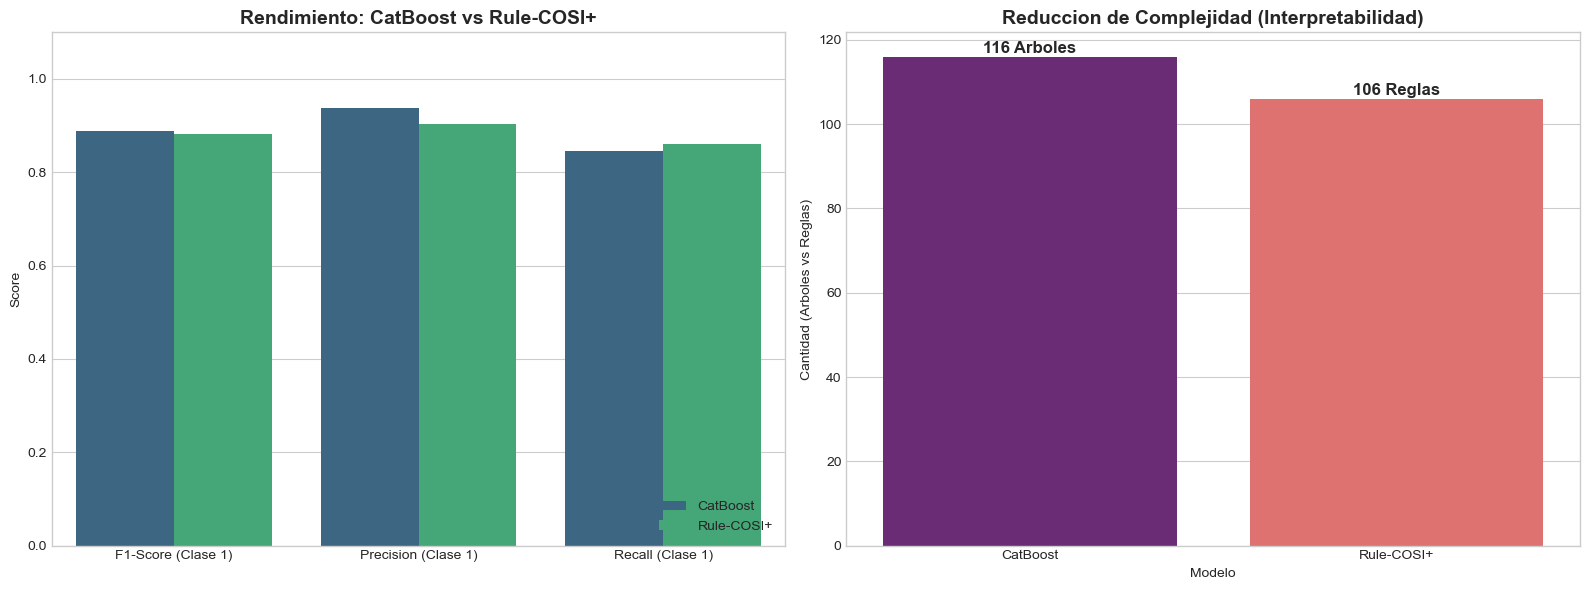


REGLAS FINALES EXTRAIDAS (CONOCIMIENTO DESCUBIERTO)
Regla 1: (debt_settlement_flag ≤ 0.500) ˄ (dti > 0.805) ˄ (dti ≤ 20.565) ˄ (fico_range_low ≤ 842.500) ˄ (last_fico_range_high > 601.500) ˄ (loan_amnt ≤ 36037.500) ˄ (recoveries ≤ 0.005) → [0]
Regla 2: (debt_settlement_flag ≤ 0.500) ˄ (dti > 0.805) ˄ (fico_range_low ≤ 842.500) ˄ (last_fico_range_high > 601.500) ˄ (loan_amnt ≤ 36037.500) ˄ (recoveries ≤ 0.005) → [0]
Regla 3: (recoveries > 0.005) → [1]
Regla 4: (debt_settlement_flag ≤ 0.500) ˄ (dti > 0.805) ˄ (dti ≤ 20.565) ˄ (fico_range_low ≤ 842.500) ˄ (last_fico_range_high > 551.500) ˄ (loan_amnt ≤ 36037.500) ˄ (recoveries ≤ 0.005) ˄ (term_num ≤ 48.000) → [0]
Regla 5: (debt_settlement_flag ≤ 0.500) ˄ (dti > 0.805) ˄ (dti ≤ 41.140) ˄ (fico_range_low ≤ 842.500) ˄ (grade ≤ 5.500) ˄ (last_fico_range_high > 556.500) ˄ (loan_amnt ≤ 36037.500) ˄ (recoveries ≤ 0.005) ˄ (term_num ≤ 48.000) ˄ (total_rec_late_fee ≤ 25.645) → [0]
Regla 6: (debt_settlement_flag ≤ 0.500) ˄ (dti > 0.805) ˄ (dti ≤ 2

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report
import pandas as pd
import numpy as np

# --- 1. EVALUACION DE CATBOOST SOBRE X_TEST (mismo conjunto que RuleCOSI+) ---
X_test_encoded_cb = mod.encode_data_like_training(X_test, cat_mappings)
threshold  = catboost_metrics['optimal_threshold']
y_pred_cb  = (catboost_model.predict_proba(X_test_encoded_cb)[:, 1] >= threshold).astype(int)

prec_1_cb, rec_1_cb, f1_1_cb, _ = precision_recall_fscore_support(y_test, y_pred_cb, average='binary')

print('\n' + '='*60)
print('CATBOOST - EVALUACION SOBRE X_TEST')
print('='*60)
print(classification_report(y_test, y_pred_cb, digits=4))

# --- 2. EVALUACION DE RULE-COSI+ SOBRE X_TEST ---
y_pred_rc = final_rc.predict(X_test_encoded)
cm_rc     = confusion_matrix(y_test, y_pred_rc)
prec_1_rc, rec_1_rc, f1_1_rc, _ = precision_recall_fscore_support(y_test, y_pred_rc, average='binary')

print('\n' + '='*60)
print('RULE-COSI+ - EVALUACION SOBRE X_TEST')
print('='*60)
print(classification_report(y_test, y_pred_rc, digits=4))

# --- 3. TABLA COMPARATIVA (ambos evaluados en el mismo X_test) ---
comparativa_tesis = pd.DataFrame({
    'Modelo':                  ['CatBoost', 'Rule-COSI+'],
    'F1-Score (Clase 1)':      [f1_1_cb,   f1_1_rc],
    'Precision (Clase 1)':     [prec_1_cb, prec_1_rc],
    'Recall (Clase 1)':        [rec_1_cb,  rec_1_rc],
    'Complejidad (#unidades)': [catboost_model.tree_count_, len(final_rc.simplified_ruleset_.rules)],
    'Tipo de Unidad':          ['Arboles', 'Reglas']
})

print('\n' + '='*60)
print('RESULTADOS FINALES PARA LA TESIS')
print('(ambos modelos evaluados sobre el mismo X_test)')
print('='*60)
print(comparativa_tesis.to_string(index=False))

# --- 4. GRAFICOS ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

df_plot = comparativa_tesis.melt(id_vars='Modelo', value_vars=['F1-Score (Clase 1)', 'Precision (Clase 1)', 'Recall (Clase 1)'])
sns.barplot(data=df_plot, x='variable', y='value', hue='Modelo', palette='viridis', ax=ax1)
ax1.set_title('Rendimiento: CatBoost vs Rule-COSI+', fontsize=14, fontweight='bold')
ax1.set_ylabel('Score')
ax1.set_xlabel('')
ax1.set_ylim(0, 1.1)
ax1.legend(loc='lower right')

sns.barplot(x='Modelo', y='Complejidad (#unidades)', data=comparativa_tesis, palette='magma', ax=ax2)
for i, val in enumerate(comparativa_tesis['Complejidad (#unidades)']):
    ax2.text(i, val + 1, f'{int(val)} {comparativa_tesis["Tipo de Unidad"][i]}', ha='center', fontweight='bold', fontsize=12)
ax2.set_title('Reduccion de Complejidad (Interpretabilidad)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Cantidad (Arboles vs Reglas)')

plt.tight_layout()
plt.show()

# --- 5. REGLAS FINALES ---
print('\n' + '='*60)
print('REGLAS FINALES EXTRAIDAS (CONOCIMIENTO DESCUBIERTO)')
print('='*60)
for i, rule in enumerate(final_rc.simplified_ruleset_.rules):
    print(f'Regla {i+1}: {rule}')
